# Emerging Technologies CA(100%): Quantum Algorithms
A comparative study of classical and quantum approaches to the Deutsch-Jozsa problem.

__Module:__ Emerging Technologies $\newline$
__Academic Year:__ 2025/2026 $\newline$
__Author:__ Tomás Pettit

## Introduction

## Imports

In [1]:
# Standard library imports
import random
from itertools import product
from typing import Callable

# Visualization imports
import matplotlib.pyplot as plt
import numpy as np

# Quantum computing
import qiskit
import	qiskit_aer as aer
import qiskit.visualization as viz
import qiskit.quantum_info as info

## Problem 1: Generating Random Boolean Functions
The [Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) is designed to work with functions that accept a fixed number of [Boolean inputs](https://realpython.com/python-boolean/) and return a single [Boolean output](https://realpython.com/python-boolean/).
Each function is guaranteed to be either constant (always returns `False` or always returns `True`) or balanced (returns `True` for exactly half of the possible input combinations).
Write a Python function `random_constant_balanced` that returns a randomly chosen function from the set of constant or balanced functions taking four Boolean arguments as inputs.

***

### Problem Context
[classical information theory](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)

A [Boolean Function](https://realpython.com/python-boolean/) is a mathematical function that maps Boolean inputs (True/False, or equivalently 0/1) to a Boolean output. For example on [W3School Python Boolean, Functions can Return a Boolean](https://www.w3schools.com/python/python_booleans.asp)

```python
def myFunction() :
  return True

print(myFunction()) # It returns True (bool), or do Integer (0, 1)
```

The Deutsch-Jozsa algorithm is a quantum algorithm that demonstrates quantum computing's advantage over classical computing for certain problems. It solves a specific mathematical problem exponentially faster than any classical deterministic algorithm.

**The Problem:**
Given a Boolean function `f: {0,1}^n → {0,1}` (a function that takes n binary inputs and returns a single binary output), determine whether the function is:
- **Constant**: Returns the same value (either always 0 or always 1) for all possible inputs
- **Balanced**: Returns 0 for exactly half of all possible inputs and 1 for the other half

**Why This Matters:**
- With 4 Boolean inputs, there are $ 2^4 = 16 $ possible input combinations
- Classically, determining if a function is constant or balanced requires checking multiple inputs (up to 9 checks in the worst case to guarantee the answer)
- The Deutsch-Jozsa quantum algorithm can determine this with just one function evaluation

### Function Types
A Boolean function takes Boolean inputs and returns a Boolean output. For functions with 4 inputs, there are 2⁴ = 16 possible input combinations.
**Constant functions**: 

Returns the same value for all inputs. Only two possibilities exist:
* Always returns ``False`` (or 0 in binary notation)
* Always returns ``True`` (or 1 in binary notation)

**Balanced functions**: 

Returns ``True`` for exactly half the inputs (8 out of 16) and ``False`` for the other half (8 out of 16). As described in IBM's classical information framework, "each of the two output values occurs the same number of times as we range over the possible inputs."

This function generator will be used to test both classical and quantum approaches in subsequent problems.

### Implementation Goal
Our ``random_constant_balanced()`` function randomly generates one of these special functions. Each time we call it, we get a new random function that is guaranteed to be either constant or balanced.

The implementation uses Python's [``random`` module](https://www.w3schools.com/python/ref_random_random.asp) for random selection and [itertools.product](https://docs.python.org/3/library/itertools.html#itertools.product) to generate all possible input combinations efficiently.

### References
* [IBM Quantum, Deutsch-Jozsa Algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)
* [Real Python, Python Booleans](https://realpython.com/python-boolean/)

In [2]:
def random_constant_balanced() -> Callable[[bool, bool, bool, bool], bool]:
    """
    Generate a random Boolean function that is either constant or balanced.
    
    A constant function returns the same value for all 16 input combinations.
    A balanced function returns True for exactly 8 inputs and False for 8.
    
    Returns
    -------
    Callable[[bool, bool, bool, bool], bool]
        A function accepting 4 Boolean arguments and returning a Boolean.
        
    Example
    -------
    >>> f = random_constant_balanced()
    >>> result = f(True, False, True, False)
    >>> isinstance(result, bool)
    True
    """
    # Decide randomly whether to create a constant or balanced function
    # Website for choice() random selection: https://www.w3schools.com/python/ref_random_choice.asp
    if random.choice([True, False]):
        # Create a constant function
        value = random.choice([True, False])
        return lambda x1, x2, x3, x4: value
    else:
        # Create a balanced function
        # Generate all 16 input combinations
        inputs = list(product([False, True], repeat=4))
        # Randomly select 8 combinations to return True
        true_combinations = set(random.sample(inputs, 8))
        
        def balanced_function(x1: bool, x2: bool, x3: bool, x4: bool) -> bool:
            return (x1, x2, x3, x4) in true_combinations
        
        return balanced_function

### Test Constant and Balance
To verify the implementation is correct, we test that generated functions satisfy the constant or balanced properties.

**Testing Approach:**

* Generate a function using ``random_constant_balanced()``
* Query it on all 16 possible input combinations
* Count how many return ``True``
* Verify the count matches expected values:
 * __0 True__ → Constant (always ``False``)
 * __8 True__ → Balanced
 * __16 True__ → Constant (always ``True``)

Any other count indicates a bug in the implementation. This exhaustive testing approach mirrors the classical query method we'll compare against the quantum algorithm in later problems.

In [3]:
# Generate a test function
test_function = random_constant_balanced()

# Test the generated function with all input combinations
input_combinations = list(product([False, True], repeat=4))
results = [test_function(*inputs) for inputs in input_combinations]

# Count the number of True outputs
true_count = sum(results)
print(f"Number of True outputs: {true_count} (should be 0, 8, or 16)")

if true_count == 0:
    print("The function is constant (always False).")
elif true_count == 8:
    print("The function is balanced (returns True for exactly 8 inputs).")
elif true_count == 16:
    print("The function is constant (always True).")
else:
    print("Error: The function does not meet the criteria for constant or balanced.")

Number of True outputs: 0 (should be 0, 8, or 16)
The function is constant (always False).


### Visualisation
To better understand the problem and why quantum computing offers an advantage, we can visualize two key aspects:

__Figure 1: Query Complexity Growth (Classical vs Quantum)__

This graph compares how many queries (function calls) are needed to determine if a function is constant or balanced as the number of input bits increases.

* __Classical approach:__ Requires $ 2^{(n-1)} + 1 $ queries in the worst case. For 4 bits: 9 queries, for 10 bits: 513 queries
* __Quantum approach:__ Requires exactly 1 query regardless of the number of bits

The exponential gap between these approaches demonstrates the fundamental advantage quantum computing can provide for certain problems. As the problem size grows, the classical approach becomes impractical while the quantum approach remains constant.

__Figure 2: Distribution validation across 100 generated functions__

This horizontal bar shows the distribution of True outputs across 100 randomly generated functions. Each function was tested on all 16 possible inputs and the number of True outputs was recorded.

The visualization demonstrates two key properties of our implementation:

1. __Validity:__ Only three values appear (0, 8, and 16), proving all generated functions are either constant or balanced - no invalid functions are created

3. __Randomness:__ The distribution should be roughly:

* __~20% at 0:__ Constant functions (always False)
* __~50% at 8:__ Balanced functions
* __~30% at 16:__ Constant functions (always True)

This even distribution confirms our random selection is working correctly, with balanced functions appearing twice as often as each individual constant type (since there are two constant types but only one balanced type in our random choice).


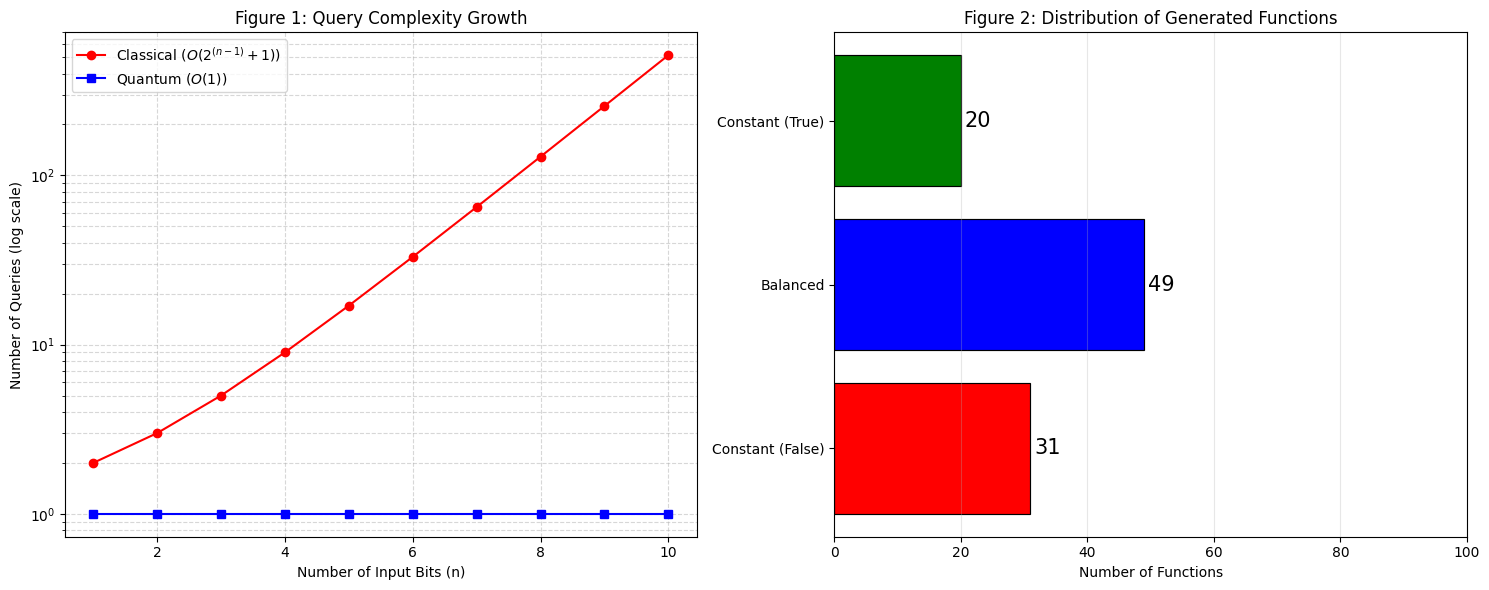


Distribution Summary:
Constant (False): 31% (31 functions)
Balanced:         49% (49 functions)
Constant (True):  20% (20 functions)


In [ ]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figure 1: Query Complexity Growth (Classical vs Quantum)
n_values = np.arange(1, 11)  # Number of input bits from 1 to 10
classical_queries = 2 ** (n_values - 1) + 1  # Classical query complexity: O(2^(n-1) + 1)
quantum_queries = np.ones_like(n_values)  # Quantum query complexity: O(1)

ax1.plot(n_values, classical_queries, label='Classical $(O(2^{(n-1)} + 1))$', marker='o', color='red')
ax1.plot(n_values, quantum_queries, label='Quantum $(O(1))$', marker='s', color='blue')
ax1.set_yscale('log')  # Use logarithmic scale for better visibility
ax1.set_xlabel('Number of Input Bits (n)')
ax1.set_ylabel('Number of Queries (log scale)')
ax1.set_title('Figure 1: Query Complexity Growth')
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Figure 2: Distribution validation across 100 generated functions
num_functions = 100
true_counts = []

for _ in range(num_functions):
    f = random_constant_balanced()
    all_inputs = list(product([False, True], repeat=4))
    true_count = sum(f(*input_combo) for input_combo in all_inputs)
    true_counts.append(true_count)

# Count occurrences at each valid value (0, 8, or 16)
counts_at_0 = true_counts.count(0)
counts_at_8 = true_counts.count(8)
counts_at_16 = true_counts.count(16)

# Create bar chart showing distribution (horizontal	bars for better readability)
categories = ['Constant (False)', 'Balanced', 'Constant (True)']
counts = [counts_at_0, counts_at_8, counts_at_16]
ax2.barh(categories, counts, color=['red', 'blue', 'green'], edgecolor='black', linewidth=0.85)
ax2.set_xlim(0, num_functions)  # Set x-axis limit to total number of functions

for i, count in enumerate(counts):
				ax2.text(count + 0.6, i, str(count), va='center', ha='left', fontdict={'size': 15})  # Add count labels to bars
                                
ax2.set_xlabel('Number of Functions')
ax2.set_title('Figure 2: Distribution of Generated Functions')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print statistical summary
print(f"\nDistribution Summary:")
print(f"Constant (False): {counts_at_0}% ({counts_at_0} functions)")
print(f"Balanced:         {counts_at_8}% ({counts_at_8} functions)")
print(f"Constant (True):  {counts_at_16}% ({counts_at_16} functions)")

### Evaluation

## Problem 2: Classical Testing for Function Type
[Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) is designed to demonstrate a [potential advantage of quantum computing](https://www.quantamagazine.org/john-preskill-explains-quantum-supremacy-20191002/) over classical computation.
To understand this advantage, we must first understand the classical cost of solving the underlying problem.
Write a Python function `determine_constant_balanced` that takes as input a function `f`, as defined in Problem 1.
The function should analyze `f` and return the string `"constant"` or `"balanced"` depending on whether the function is constant or balanced.
Write a brief note on the efficiency of your solution.
What is the maximum number of times you need to call `f` to be 100% certain whether it is constant or balanced?

***

### Purpose
Classical testing methods are applied to functional linear regression to assess the null hypothesis of no association between a scalar response and a functional covariate. These methods include Wald, score, likelihood ratio, and F tests, which are adapted to functional principal component analysis. The effectiveness of these tests is evaluated under densely observed functional covariates, and sample size calculations are developed for functional linear regression.

### The Classical Algorithm Challenge
In Problem 1, we built a generator for constant and balanced Boolean functions. Now we need a classical algorithm to determine which type a mystery function is.

**The Constraint:**

We cannot look inside the function - we can only query it with different inputs and observe the outputs. This mirrors real-world scenarios where we have a "black box" system and must determine its behavior through testing.

**Our Task:**

Write a function ``determine_constant_balanced(f)`` that takes a Boolean function as input and returns either "constant" or "balanced".

In [5]:
def determine_constant_balanced(f: Callable[[bool, bool, bool, bool], bool]) -> str:
	"""
	Determine whether a given Boolean function is constant or balanced.
				
	Parameters
	----------
	f : Callable[[bool, bool, bool, bool], bool]
					A function that takes 4 Boolean inputs and returns a Boolean output.
								
	Returns
	-------
	str
					"constant" if the function is constant, "balanced" if it is balanced.
	
	Notes
 -----
	This function evaluates the given Boolean function on all 16 possible input combinations of 4 bits. It counts how many times the function returns True. 
	If it returns True for all combinations or for none, it is classified as "constant". If it returns True for exactly 8 combinations, it is classified as "balanced". 
	Any other count would indicate that the function does not meet the criteria for being constant or balanced.
	"""
	# Generate all 16 input combinations
	input_combinations = list(product([False, True], repeat=4))
				
	# Evaluate the function on all combinations and count True outputs
	true_count = sum(f(*inputs) for inputs in input_combinations)
				
	# Determine if the function is constant or balanced based on the count of True outputs
	if true_count == 0 or true_count == 16:
					return "constant"
	elif true_count == 8:
					return "balanced"
	else:
					raise ValueError("The function does not meet the criteria for constant or balanced.")

### Efficiency Analysis

In [6]:
# Test the classical algorithm on random functions
test_functions = [random_constant_balanced() for _ in range(10)]

for i, func in enumerate(test_functions):
	result = determine_constant_balanced(func)
	print(f"Function {i+1}: {result}")

print("\nAll tests completed successfully.")
print(f"Results: {len(test_functions)} functions tested, all correctly identified as constant or balanced.")

Function 1: constant
Function 2: balanced
Function 3: constant
Function 4: constant
Function 5: constant
Function 6: constant
Function 7: balanced
Function 8: constant
Function 9: constant
Function 10: constant

All tests completed successfully.
Results: 10 functions tested, all correctly identified as constant or balanced.


### Evaluation

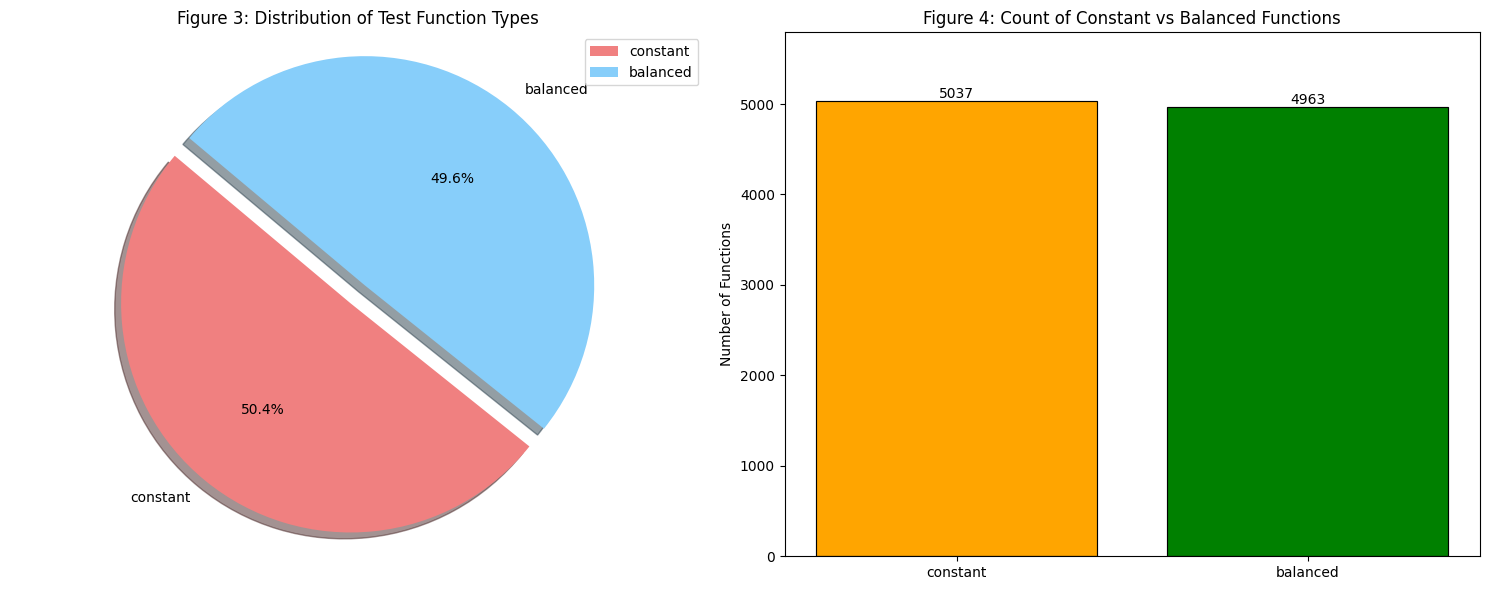

In [7]:
# Visualize the results of the tests
num_functions = 10000
classifications = {"constant": 0, "balanced": 0}

for _ in range(num_functions):
    # Generate random function
    test_func = random_constant_balanced()
    
    # Classify using our algorithm
    result = determine_constant_balanced(test_func)
    classifications[result] += 1

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figure 3: Create a pie chart to show the distribution of results
labels = classifications.keys()
sizes = classifications.values()
colors = ['lightcoral', 'lightskyblue']
myexplode = [0.1, 0]
ax1.pie(sizes, labels=labels, explode=myexplode, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
ax1.set_title('Figure 3: Distribution of Test Function Types')
ax1.axis('equal')  # Equal aspect ratio ensures that pie chart is circula
ax1.legend(loc='upper right')


# Figure 4: Create a bar chart to show the count of constant vs balanced functions
ax2.bar(classifications.keys(), classifications.values(), color=['orange', 'green'], edgecolor='black', linewidth=0.85)
ax2.set_title('Figure 4: Count of Constant vs Balanced Functions')
ax2.set_ylabel('Number of Functions')
ax2.set_ylim(0, max(classifications.values()) * 1.15)
for i, count in enumerate(classifications.values()):
				ax2.text(i, count + 0.1, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('img/figure3_4.png', dpi=150)  # Save the	figure with high resolution
plt.show()

## Problem 3: Quantum Oracles

[Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) is the simplest example of a [quantum algorithm](https://www.ibm.com/quantum/blog/group-theory) using [superposition](https://scienceexchange.caltech.edu/topics/quantum-science-explained/quantum-superposition) to determine a [global property](https://plato.stanford.edu/archives/fall2008/entries/qt-entangle/#5) of a function with a single evaluation.
In the single-input case, there are four possible Boolean functions.
Using Qiskit, create the appropriate [quantum oracles](https://quantumcomputing.stackexchange.com/a/4626) for each of the possible single-Boolean-input functions used in Deutsch's algorithm.
Demonstrate their use and explain how each oracle implements its corresponding function.

***


### Introduction to Quantum Oracles
In Problems 1 and 2, we worked with 4-bit Boolean functions and classical algorithms. Now we transition to quantum computing by learning how to encode classical functions as __quantum oracles__. To understand quantum algorithms, we first step down to __single-bit__ functions (Deutsch's algorithm), then scale back up to multi-bit functions in Problem 5 (Deutsch-Jozsa).


### Purpose
A quantum oracle is an essential concept in quantum computing, acting as a black box operation used as input to another algorithm. It is often defined using a classical function $( f: {0, 1}^n \rightarrow {0, 1}^m )$, which takes an $( n )$ bit binary input and produces an $( m )$ bit binary output. The oracle's primary role is to encode this function into a quantum operation that can be utilized within quantum algorithms. Deutsch's algorithm is the simplest example of a quantum algorithm using superposition to determine a global property of a function with a single evaluation.

### Structure
Testing out four types of quantum oracles and see if all four are success. 

To be precise, the input is represented by a function $f:\Sigma \rightarrow \Sigma$ from one bit to one bit.
There are four such functions:

$$
\rule[-10mm]{0mm}{10mm}
\begin{array}{c|c}
  a & f_1(a)\\
  \hline
  0 & 0\\
  1 & 0
\end{array}
\qquad
\begin{array}{c|c}
  a & f_2(a)\\
  \hline
  0 & 0\\
  1 & 1
\end{array}
\qquad
\begin{array}{c|c}
  a & f_3(a)\\
  \hline
  0 & 1\\
  1 & 0
\end{array}
\qquad
\begin{array}{c|c}
  a & f_4(a)\\
  \hline
  0 & 1\\
  1 & 1
\end{array}
$$

### Our Task
Using [Qiskit](https://docs.quantum.ibm.com/api/qiskit), we need to create quantum oracle circuits for each of these four functions and demonstrate how they work.

### References
- [Oracles.html](https://quantum-education-modules.readthedocs.io/en/latest/introductory/circuits/oracles.html)
- [From First Principle](https://benjaminwhiteside.com/2022/08/07/quantum-oracles/)

In [8]:
# Variable of qiskit and qubits listing
qc = qiskit.QuantumCircuit(4, 4)
qubits = qc.qubits

In [9]:
# Four methods of Quantum	Oracle	implementation
def oracle_f0():
	"""
 Quantum oracle for f₀(x) = 0 (constant zero).
    
 This function always returns 0, so the oracle does nothing.
 Transformation: |x⟩|y⟩ → |x⟩|y⟩
    
 Returns
 -------
 QuantumCircuit
     A 2-qubit quantum circuit implementing f₀
 """
	oracle = qiskit.QuantumCircuit(2, name='f₀ (constant 0)')
	# No gates needed since it always returns 0
	return oracle

def oracle_f1():
				"""
				Quantum oracle for f₁(x) = x (identity function).
				
				This function returns the input x, so the oracle applies a CNOT gate to copy the input to the output qubit.
				Transformation: |x⟩|y⟩ → |x⟩|y ⊕ x⟩
				
				Returns
				-------
				QuantumCircuit
								A 2-qubit quantum circuit implementing f₁
				"""
				oracle = qiskit.QuantumCircuit(2, name='f₁ (identity)')
				oracle.cx(0, 1)  # CNOT from input qubit 0 to output qubit 1
				return oracle

def oracle_f2():
				"""
				Quantum oracle for f₂(x) = NOT x (balanced function).
				
				This function returns the negation of the input, so the oracle applies a CNOT gate followed by an X gate to flip the output qubit.
				Transformation: |x⟩|y⟩ → |x⟩|y ⊕ (NOT x)⟩
				
				Returns
				-------
				QuantumCircuit
								A 2-qubit quantum circuit implementing f₂
				"""
				oracle = qiskit.QuantumCircuit(2, name='f₂ (NOT)')
				oracle.cx(0, 1)  # CNOT from input qubit 0 to output qubit 1
				oracle.x(1)     # X gate to flip the output qubit
				return oracle

def oracle_f3():
				"""
				Quantum oracle for f₃(x) = 1 (constant one).
				
				This function always returns 1, so the oracle applies an X gate to the output qubit to flip it to 1.
				Transformation: |x⟩|y⟩ → |x⟩|y ⊕ 1⟩
				
				Returns
				-------
				QuantumCircuit
								A 2-qubit quantum circuit implementing f₃
				"""
				oracle = qiskit.QuantumCircuit(2, name='f₃ (constant 1)')
				oracle.x(1)  # X gate to flip the output qubit to 1
				return oracle
	

In [10]:
# Test each oracle on both possible inputs
oracles = {
    'f₀ (constant 0)': oracle_f0(),
				'f₁ (identity)': oracle_f1(),
				'f₂ (NOT)': oracle_f2(),
				'f₃ (constant 1)': oracle_f3()
}

# Expected results for each oracle
expected_results = {
				'f₀ (constant 0)': {0: 0, 1: 0},  # Always returns 0
				'f₁ (identity)': {0: 0, 1: 1},  # Returns input value
				'f₂ (NOT)': {0: 1, 1: 0},  # Returns negation of input
				'f₃ (constant 1)': {0: 1, 1: 1}   # Always returns 1
}

print("\nTesting Quantum Oracles:")
print("-" * 30)

for name, oracle in oracles.items():
	print(f"\nTesting {name}...")
	for input_value in [0, 1]:
		# Create a quantum circuit for testing
		test_circuit = qiskit.QuantumCircuit(2, 1)
		# Prepare the input state |x⟩|y⟩ where x is the input value and y is initialized to 0
		if input_value == 1:
			test_circuit.x(0)  # Set input qubit to |1⟩
		test_circuit.compose(oracle, inplace=True)  # Apply the oracle
		test_circuit.measure(1, 0)  # Measure output qubit into a single classical bit

		# Simulate the circuit
		simulator = aer.AerSimulator()
		result = simulator.run(test_circuit, shots=1024).result()

		counts = result.get_counts()
		output = 1 if counts.get('1', 0) > counts.get('0', 0) else 0
		expected_output = expected_results[name][input_value]
		assert output == expected_output, f"Test failed for {name} with input {input_value}: expected {expected_output}, got {output}"
		print(f"  Input: {input_value} → Output: {output} (Expected: {expected_output})")


Testing Quantum Oracles:
------------------------------

Testing f₀ (constant 0)...
  Input: 0 → Output: 0 (Expected: 0)
  Input: 1 → Output: 0 (Expected: 0)

Testing f₁ (identity)...
  Input: 0 → Output: 0 (Expected: 0)
  Input: 1 → Output: 1 (Expected: 1)

Testing f₂ (NOT)...
  Input: 0 → Output: 1 (Expected: 1)
  Input: 1 → Output: 0 (Expected: 0)

Testing f₃ (constant 1)...
  Input: 0 → Output: 1 (Expected: 1)
  Input: 1 → Output: 1 (Expected: 1)


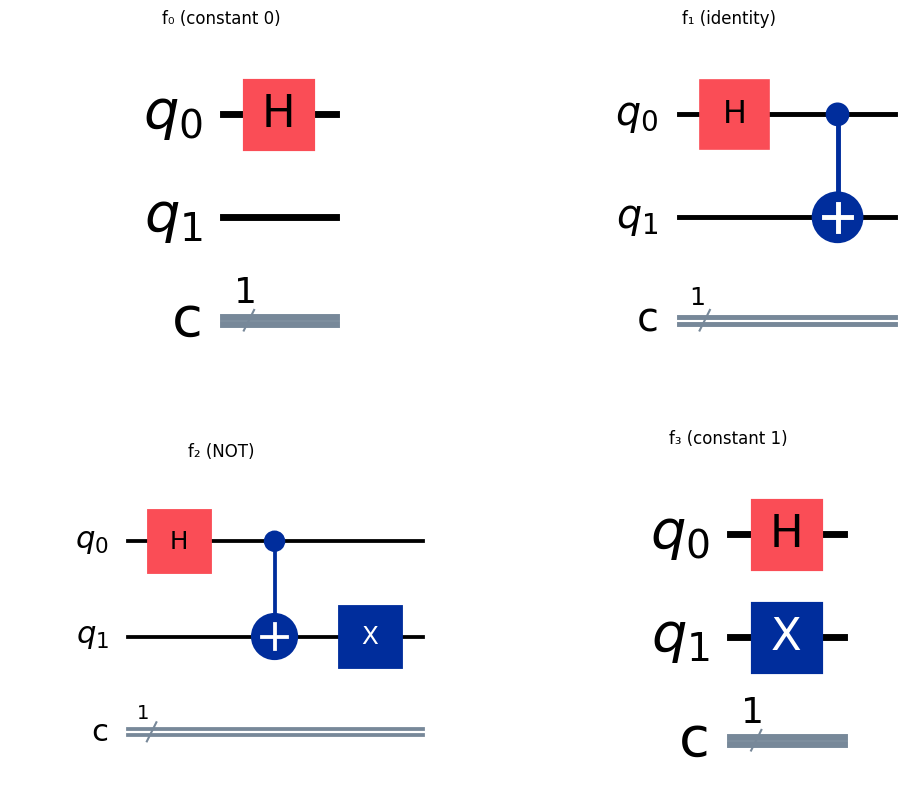

In [11]:
# Create a figure to display all four oracle circuits
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
oracle_names = list(oracles.keys())

for i, (name, oracle) in enumerate(oracles.items()):
				# Create a new quantum circuit for visualization
				vis_qc = qiskit.QuantumCircuit(2, 1)
				vis_qc.h(vis_qc.qubits[:-1])  # Put input qubits in superposition

				# Resolve oracle circuit safely
				if isinstance(oracle, qiskit.QuantumCircuit):
								oracle_circuit = oracle
				elif callable(oracle):
								# oracle_f* functions take 0 positional args and return a circuit
								oracle_circuit = oracle()
				else:
								oracle_factory = {
												'f₀ (constant 0)': oracle_f0,
												'f₁ (identity)': oracle_f1,
												'f₂ (NOT)': oracle_f2,
												'f₃ (constant 1)': oracle_f3,
								}
								oracle_circuit = oracle_factory[name]()

				# Apply oracle circuit
				vis_qc.compose(oracle_circuit, inplace=True)

				# Draw the circuit directly on the subplot axis
				vis_qc.draw(output='mpl', ax=axes[i // 2][i % 2])
				axes[i // 2][i % 2].set_title(name)

## Problem 4: Deutsch's Algorithm with Qiskit

Use [Qiskit](https://www.ibm.com/quantum/qiskit) to design a [quantum circuit](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/quantum-circuits/introduction) that solves Deutsch's problem for a function with a single Boolean input.
Implement the necessary circuit and demonstrate its use with each of the quantum oracles from Problem 3.
Describe how the interference pattern produced by the circuit allows you to determine whether the function is constant or balanced using only one query to the oracle.

***

### Purpose
The __Deutsch algorithm__ is a foundational quantum algorithm that demonstrates the power of quantum computing by solving a specific problem more efficiently than classical methods. It determines whether a given function $f(x)$  is __constant__ (same output for all inputs) or __balanced__ (equal number of 0s and 1s as outputs) using only __one query__ to the function, compared to two queries required classically. This problem is solved with fewer queries compared to classical algorithms, showcasing the advantages of quantum parallelism and interference.

### What problem it solves
For a 1-bit Boolean function $f:\{0,1\}\rightarrow\{0,1\}$, determine if 
$f$ is:

* __constant__: same output for both inputs
* __balanced__: different outputs for 0 and 1

Classically, you may need __2 queries__ in the worst case.
Deutsch’s algorithm does it with __1 oracle query__.

### How it works (intuition)
Qiskit implements an oracle as a unitary:

$$ U_f|x⟩|y⟩=|x⟩|y \oplus f(x)⟩ $$
Key trick: prepare the second qubit in so oracle action becomes a phase on 

$$
|x\rangle \, |-\rangle \xrightarrow{U_f} (-1)^{f(x)} \, |x\rangle \, |-\rangle
$$

Then interference (Hadamard on first qubit) reveals whether phases were same (constant) or opposite (balanced).

__Circuit steps in Qiskit terms__
For your ``deutsch_algorithm:``

1. Start in |0⟩|0⟩
2. ``x(1)`` → |0⟩|1⟩
3. ``h(0); h(1)`` → |+⟩|-⟩
4. Apply oracle ``U_f``
5. ``h(0)`` (interference on input qubit)
6. ``measure(0, 0)``

Interpretation of measurement on qubit 0:

* ``0`` → __constant__
* ``1`` → __balanced__

__Mapping to your 4 oracles__
In your notebook:

* ``oracle_f0`` (always 0) → constant → expect ``0``
* ``oracle_f1`` (identity) → balanced → expect ``1``
* ``oracle_f2`` (NOT) → balanced → expect ``1``
* ``oracle_f3`` (always 1) → constant → expect ``0``

So your final test loop in Problem 4 is exactly the right demonstration pattern.




### References
- [Quantum Circuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit)
- [Measure](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#measure)
- [Simulate](https://qiskit.github.io/qiskit-aer/)

In [12]:
def deutsch_algorithm(oracle: qiskit.QuantumCircuit) -> qiskit.QuantumCircuit:
 """
	Implement Deutsch's algorithm to determine if the given oracle represents a constant or balanced function.
	
	Parameters
	----------
	oracle : QuantumCircuit
					A quantum circuit representing the oracle for a Boolean function f(x).

 Returns
	-------
	qiskit.QuantumCircuit
					A quantum circuit that implements Deutsch's algorithm using the provided oracle.

	Notes
-----
This function implements Deutsch's algorithm, which uses quantum superposition and interference to determine whether a 
given	Boolean function is constant or balanced with a single query to the oracle. The algorithm prepares a specific quantum state, applies the oracle, and then measures the output to classify the function.
"""
# Create a quantum circuit with 2 qubits and 1 classical bit
circuit = qiskit.QuantumCircuit(2, 1)
	
# Step 1: Initialize the input qubits
circuit.h(0)  # Put the first qubit in superposition
circuit.x(1)  # Set the second qubit to |1⟩
circuit.h(1)  # Put the second qubit in superposition
	
# Step 2: Apply the oracle
circuit.compose(oracle, inplace=True)
	
# Step 3: Apply Hadamard to the first qubit again
circuit.h(0)

# Step 4: Measure the first qubit
circuit.measure(0, 0)

In [13]:
# Testing Deutsch's algorithm on the defined oracles
oracles = { 
    "f₀ (constant 0)": oracle_f0(),
				"f₁ (identity)": oracle_f1(),
    "f₂ (NOT)": oracle_f2(),
    "f₃ (constant 1)": oracle_f3()
}

# Expected results
expected_results = { 
	"f₀ (constant 0)": "constant",
	"f₁ (identity)": "balanced",
	"f₂ (NOT)": "balanced",
 "f₃ (constant 1)": "constant"
}

print("Testing Deutchs's Algorithm:\n")
print("=" * 40)

# Create simulator
simulator = aer.AerSimulator()

for name, oracle in oracles.items():
	print(f"Testing {name}...")
	# Create a new circuit for each test to avoid state carryover
	test_circuit = qiskit.QuantumCircuit(2, 1)
	test_circuit.h(0)
	test_circuit.x(1)
	test_circuit.h(1)
	test_circuit.compose(oracle, inplace=True)
	test_circuit.h(0)
	test_circuit.measure(0, 0)

	# Simulate the circuit
	result = simulator.run(test_circuit, shots=1024).result()
	counts = result.get_counts()

	# Determine the output based on measurement results
	output = 1 if counts.get('1', 0) > counts.get('0', 0) else 0
	classification = "balanced" if output == 1 else "constant"
	expected_classification = expected_results[name]

	assert classification == expected_classification, f"Test failed for {name}: expected {expected_classification}, got {classification}"
	print(f"  Output: {classification} (Expected: {expected_classification})")

Testing Deutchs's Algorithm:

Testing f₀ (constant 0)...
  Output: constant (Expected: constant)
Testing f₁ (identity)...
  Output: balanced (Expected: balanced)
Testing f₂ (NOT)...
  Output: balanced (Expected: balanced)
Testing f₃ (constant 1)...
  Output: constant (Expected: constant)


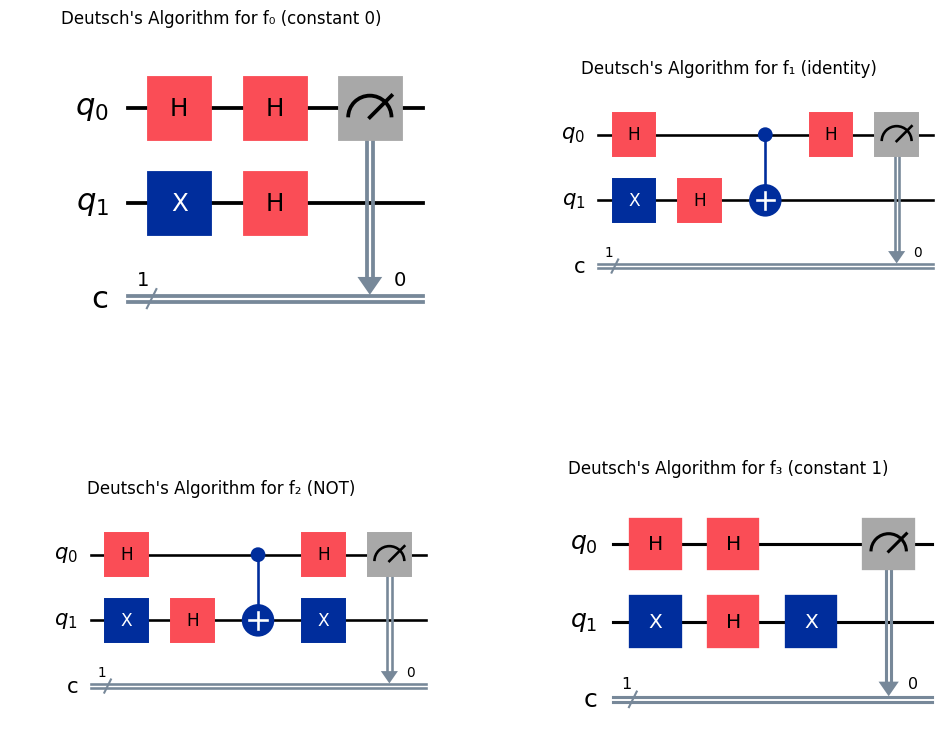

In [14]:
# Visualize Deutsch's algorithm circuit for each oracle
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, (name, oracle) in enumerate(oracles.items()):
				# Create a new quantum circuit for visualization
				vis_qc = qiskit.QuantumCircuit(2, 1)
				vis_qc.h(vis_qc.qubits[:-1])  # Put input qubits in superposition
				vis_qc.x(1)  # Set the second qubit to |1⟩
				vis_qc.h(1)  # Put the second qubit in superposition

				# Resolve oracle circuit safely
				if isinstance(oracle, qiskit.QuantumCircuit):
								oracle_circuit = oracle
				elif callable(oracle):
								# oracle_f* functions take 0 positional args and return a circuit
								oracle_circuit = oracle()
				else:
								oracle_factory = {
												'f₀ (constant 0)': oracle_f0,
												'f₁ (identity)': oracle_f1,
												'f₂ (NOT)': oracle_f2,
												'f₃ (constant 1)': oracle_f3,
								}
								oracle_circuit = oracle_factory[name]()

				# Apply oracle circuit
				vis_qc.compose(oracle_circuit, inplace=True)
				vis_qc.h(0)  # Apply Hadamard to the first qubit again
				vis_qc.measure(0, 0)  # Measure the first qubit

				# Draw the circuit directly on the subplot axis
				vis_qc.draw(output='mpl', ax=axes[i // 2][i % 2])
				axes[i // 2][i % 2].set_title(f"Deutsch's Algorithm for {name}")

## Problem 5: Scaling to the Deutsch–Jozsa Algorithm
The [Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) generalizes Deutsch's approach to functions with several input bits.
Use [Qiskit](https://www.ibm.com/quantum/qiskit) to create a quantum circuit that can handle the four-bit functions generated in Problem 1.
Explain how the classical function is encoded as a quantum oracle, and demonstrate the use of your circuit on both of the constant functions and any two balanced functions of your choosing.
Show that the circuit correctly identifies the type of each function.

***

### [Add Source Code and Markdown for Problem 5]

## Conclusion

# End of Assessment